In [31]:
import sys
import os
os.chdir('/zhome/71/c/146676/main/')
import time
import SimpleITK as sitk
import numpy as np
from astropy.io import fits
from helpers import module_auxiliary as ma
import tifffile
from multiprocessing import Pool
import matplotlib.pyplot as plt
from helpers import extended_data as ed
from cil.recon import FBP
#from cil.plugins.astra import FBP
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.optimisation.functions import L2NormSquared, L1Norm, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, \
                                       ZeroFunction
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
import h5py
from cil.utilities.display import show_geometry
from scipy.ndimage import uniform_filter1d
from cil.processors import Slicer
from scipy.interpolate import interp1d
from loaders import stitcher_XA
from loaders import loader_XA_to_NA
import SimpleITK as sitk
from cil.recon import FDK

In [2]:
c0 = 0
c1 = 2000

y0 = 120
y1 = 240

pad = 30

In [3]:
def zero_pad_3d(array: np.ndarray, N: int,value=0) -> np.ndarray:
    """
    Pads a 3D NumPy array with zeros along the last two dimensions by N pixels.
    The first dimension (axis=0) remains unchanged.

    Parameters:
    array (np.ndarray): Input 3D array.
    N (int): Number of pixels to pad along the last two dimensions.

    Returns:
    np.ndarray: Zero-padded 3D array.
    """
    if N < 0:
        raise ValueError("Padding size N must be non-negative")
    
    pad_width = ((0, 0), (0, 0), (N, N))  # No padding on axis=0, N on other axes
    return np.pad(array, pad_width, mode='constant', constant_values=0)

In [4]:
# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_ct_integrated/scan-0339_pilatus_integrated.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dataset = file['entry']['data1d']['I'][:][:,c0:c1]  # Replace 'your_dataset' with the actual name of the dataset
    dataset  = dataset.reshape(181, 362, c1-c0).transpose([2,0,1])
    two_theta = file['entry']['data1d']['2th'][:]

# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_reconstructions/scan-339_recon.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    recon_gridrec = (file['reconstructed']['gridrec'][:]/500).transpose([2,0,1])[c0:c1,y0:y1]
     # Replace 'your_dataset' with the actual name of the dataset
     
    # Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_attenuation/scan-0339_xspress3-dtc-2d.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)


dataset2 = np.load('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/filtered_integrations/median_clipped_0_6.npy')
dataset = np.transpose(dataset2/200,[2,0,1])[:][:]

17.97740866749365
FDK recon

Input Data:
	angle: 181
	vertical: 2000
	horizontal: 362

Reconstruction Volume:
	vertical: 2000
	horizontal_y: 362
	horizontal_x: 362

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 10
	Filter_inplace: False



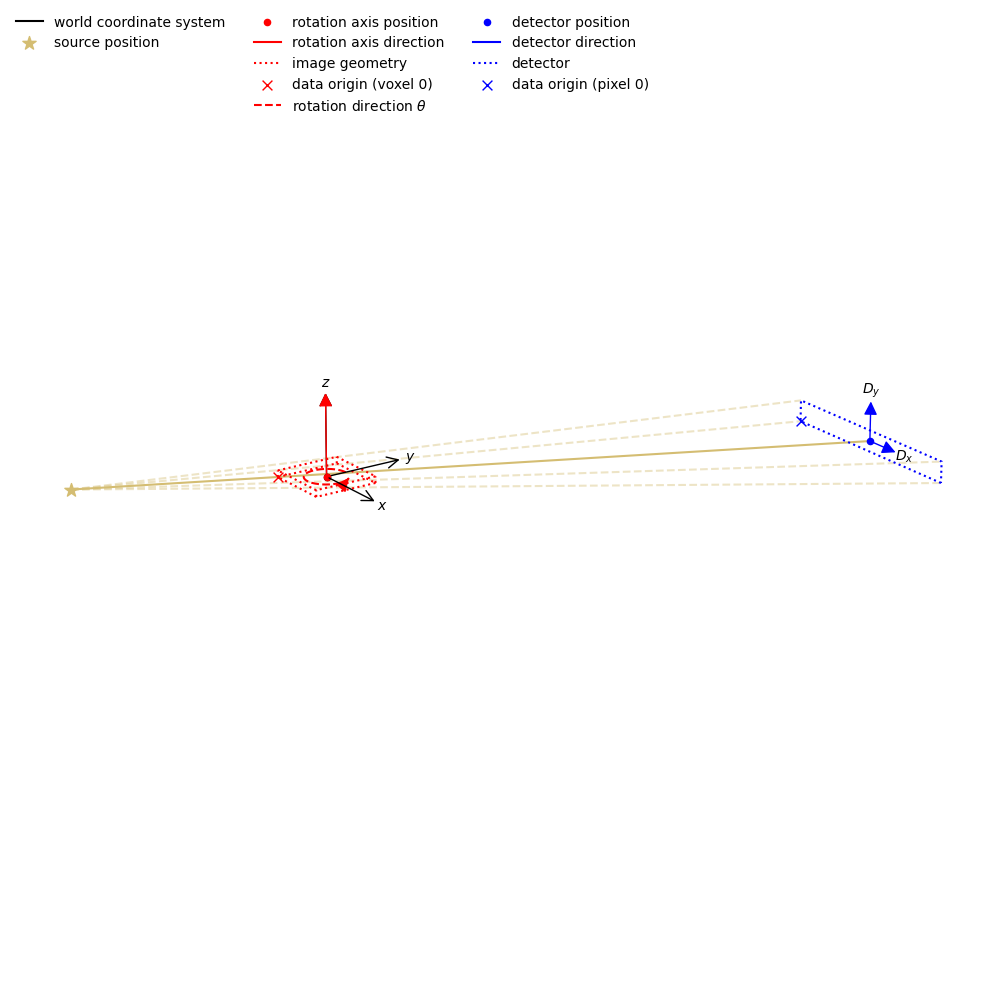

In [48]:
pad = 30
rel = (1e3*dataset/data_att).astype(np.float32)
data = rel# - np.mean(rel[:,-10:])
data_= zero_pad_3d(data, pad,value=np.mean(data[:,-10:]))


nchannels,ntheta, nx = np.shape(data)
nchannels,ntheta, nx_ = np.shape(data_)
recon_nolog = np.zeros((nchannels, y1-y0, nx))
angles = range(0,ntheta)

source_pos = -1
det_pos = 2.24
pix_n_vert = nx
pix_size_vert = 1/nx
max_2theta = np.degrees(np.arcsin(pix_n_vert*pix_size_vert/(det_pos-source_pos)))
print(max_2theta)
ag = AcquisitionGeometry.create_Cone3D(source_position = [-1/2,source_pos,0],
                 detector_position = [1,det_pos,0],
                 detector_direction_x=[1, 0, 0],
                detector_direction_y=[0, 0, 1],
                rotation_axis_position=[0, 0, 0], 
                rotation_axis_direction=[0, 0, 1],
                units='units distance')\
                .set_labels(['vertical','angle', 'horizontal'])\
                .set_angles(angles)

ag.set_panel(num_pixels = [pix_n_vert,2000], pixel_size=(pix_size_vert, 1/20000), origin='bottom-left')
ig = ag.get_ImageGeometry


data_cil = AcquisitionData(data, geometry=ag)
data_cil.reorder('tigre')
fdk = FDK(data_cil)

out = fdk.run()

show_geometry(ag)


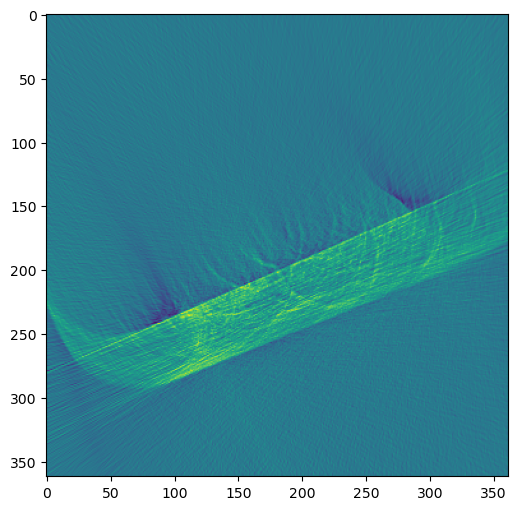

In [50]:
recon = out.as_array()
plt.close('all')
plt.figure(figsize=(6,6))
plt.imshow(recon[1000])
plt.show()

In [ ]:

data_ = AcquisitionData(data_, geometry=ag)
data_.reorder('astra')
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()
device = 'gpu'

fbp_recon = ig.allocate()
ag_channel = ag.get_slice(channel=0)
ig_channel = ig.get_slice(channel=0)